# Nathan Day

### Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### 1.1 Method of Fourier Transform

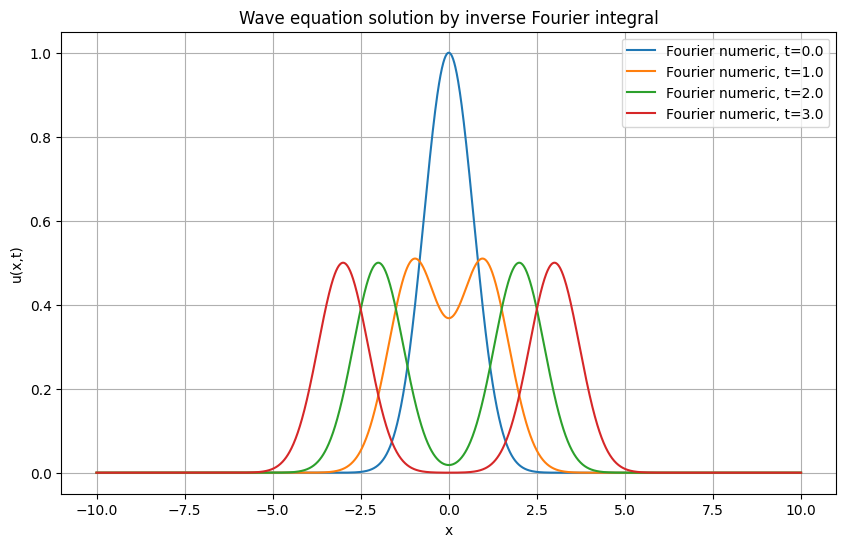

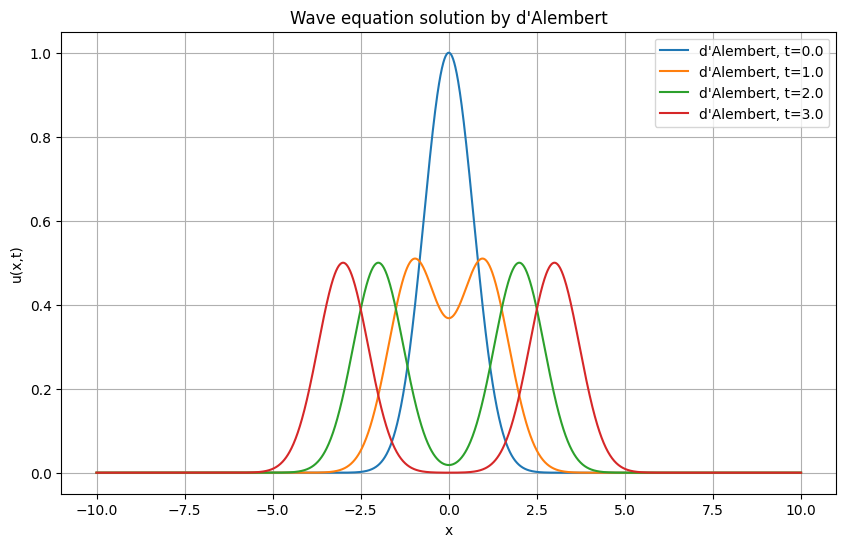

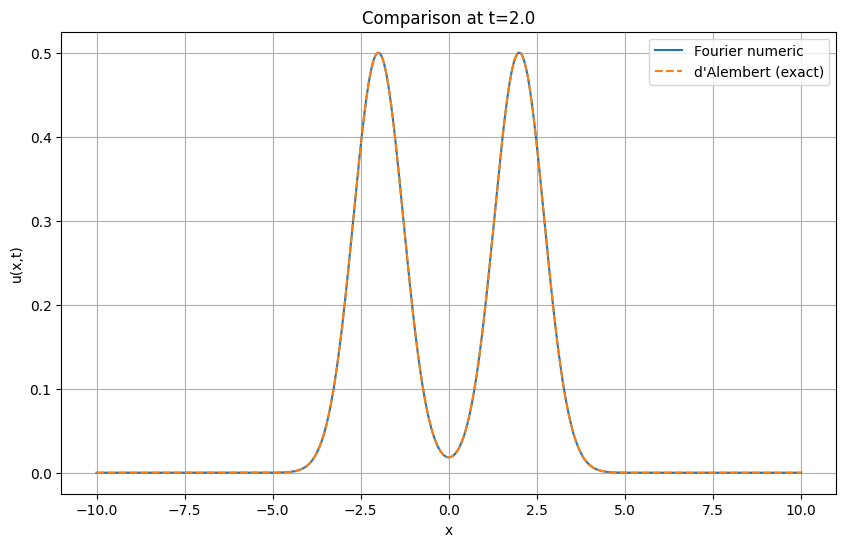

In [ ]:
# 1) Apply Fourier transform

# Transform the PDE:
#   u_tt = c^2 u_xx

# Apply F in x:
#   û_tt(k,t) = c^2 F{u_xx} = c^2 (-(k^2) û(k,t))

# So this means:
#   û_tt + (c^2 k^2) û = 0

# Therefore the initial conditions transform to:
#   û(k,0)   = f̂(k) = ∫ f(x) e^{-ikx} dx
#   û_t(k,0) = ĝ(k) = ∫ g(x) e^{-ikx} dx


# 2) Solve the transformed ODE including k=0

# For k = 0, the ODE is:
#   û_tt + (ck)^2 û = 0

# General solution:
#   û(k,t) = A(k) cos(ck t) + B(k) sin(ck t)

# Recall the information:
#   û(k,0) = A(k) = f̂(k)
#   û_t(k,t) = -A(k) (ck) sin(ck t) + B(k) (ck) cos(ck t)
#   û_t(k,0) = B(k) (ck) = ĝ(k)  ->  B(k) = ĝ(k)/(ck)

# Hence (k = 0):
# û(k,t) = f̂(k) cos(ck t) + ĝ(k)/(ck) sin(ck t)
#
# k = 0 case by limiting argument:
# ODE then must becomes û_tt(0,t) = 0, so û(0,t) = f̂(0) + ĝ(0) t,
# --> which matches limit of sin(ck t)/(ck) -> t and cos(0)->1


# 3) Invert the transform

# u(x,t) = (1/2π) ∫ [ f̂(k) cos(ck t) + ĝ(k)/(ck) sin(ck t) ] e^{ikx} dk


# 4) Specific problem: f(x)=e^{-x^2}, g(x)=0

# (a) Write û(k,t) in terms of f̂(k):

# Since g=0 -> ĝ(k)=0, so
# û(k,t) = f̂(k) cos(ck t)

# With our Fourier statement (or convention) that we have, the transform of e^{-x^2} is:
# f̂(k) = ∫_{-∞}^{∞} e^{-x^2} e^{-ikx} dx = sqrt(pi) * exp(-k^2/4)

def f_hat_gaussian(k):
    return np.sqrt(np.pi) * np.exp(-(k**2)/4)

def u_hat(k, t, c=1.0):
    # g=0 case
    return f_hat_gaussian(k) * np.cos(c * k * t)

# (b) Numerically evaluate inverse Fourier integral and plot for different times

# u(x,t) = (1/2π) ∫_{-∞}^{∞} û(k,t) e^{ikx} dk

# Here û is real and even (f̂ even, cos even), so the result is real and we can use:
# u(x,t) = (1/π) ∫_{0}^{∞} f̂(k) cos(ck t) cos(kx) dk

def u_fourier_numeric(x_grid, t, c=1.0, Kmax=50.0, Nk=2000):
    k = np.linspace(0.0, Kmax, Nk)
    fh = f_hat_gaussian(k)
    integrand_base = fh * np.cos(c * k * t)  # shape (Nk,)

    # For each x: integrand = integrand_base * cos(kx)
    # vectorize using outer product
    cos_kx = np.cos(np.outer(k, x_grid))
    integrand = integrand_base[:, None] * cos_kx

    # trapezoid rule in k for each x
    integral = np.trapezoid(integrand, k, axis=0)
    return (1.0/np.pi) * integral

# (c) General solution using d'Alembert and compare plots

# d'Alembert for whole line:
#   u(x,t) = 1/2 [ f(x-ct) + f(x+ct) ] + (1/(2c)) ∫_{x-ct}^{x+ct} g(s) ds

# Note that here g=0:
#   u(x,t) = 1/2 [ e^{-(x-ct)^2} + e^{-(x+ct)^2} ]

def u_dalembert(x, t, c=1.0):
    return 0.5*(np.exp(-(x - c*t)**2) + np.exp(-(x + c*t)**2))

# Now that we've got the hard stuff done, plot and run time!
c = 1.0
x = np.linspace(-10, 10, 2000)
times = [0.0, 1.0, 2.0, 3.0]

Kmax = 60.0
Nk = 2000

plt.figure(figsize=(10, 6))
for t in times:
    u_num = u_fourier_numeric(x, t, c=c, Kmax=Kmax, Nk=Nk)
    plt.plot(x, u_num, label=f"Fourier numeric, t={t}")

plt.title("Wave equation solution by inverse Fourier integral")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for t in times:
    u_ex = u_dalembert(x, t, c=c)
    plt.plot(x, u_ex, label=f"d'Alembert, t={t}")

plt.title("Wave equation solution by d'Alembert")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

# Overlay comparison at one time to visually confirm for my sanity
t_check = 2.0
u_num = u_fourier_numeric(x, t_check, c=c, Kmax=Kmax, Nk=Nk)
u_ex  = u_dalembert(x, t_check, c=c)

plt.figure(figsize=(10, 6))
plt.plot(x, u_num, label="Fourier numeric")
plt.plot(x, u_ex,  "--", label="d'Alembert (exact)")
plt.title(f"Comparison at t={t_check}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

### 1.2 Methods of Separation of Variables

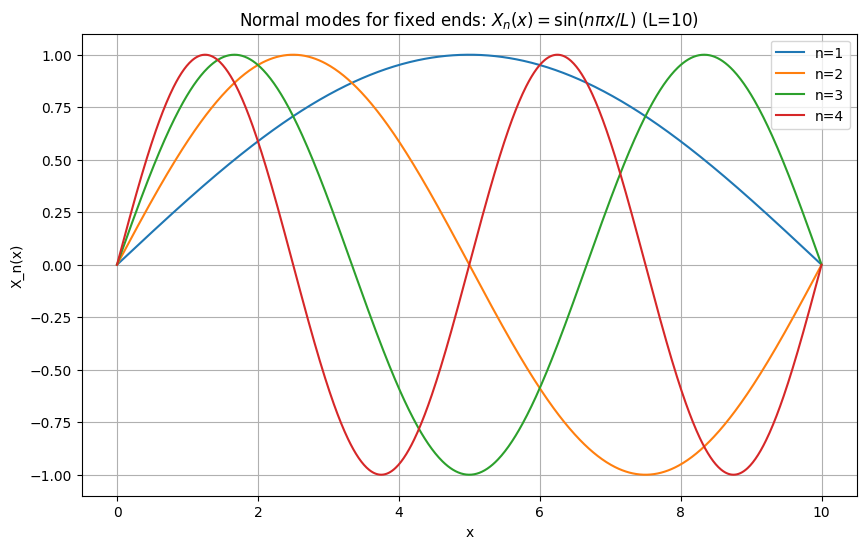

Structure you should notice:
- Each mode is a sine wave with nodes at x=0 and x=L.
- Mode n has n half-waves on [0,L] and (n-1) interior nodes.
- Higher n -> more oscillations -> captures finer spatial detail in the solution.
- The solution is a sum of modes; as N → ∞ you can represent more complicated shapes is what I am understanding.
Used N = 200 sine modes for the Fourier series approximation.


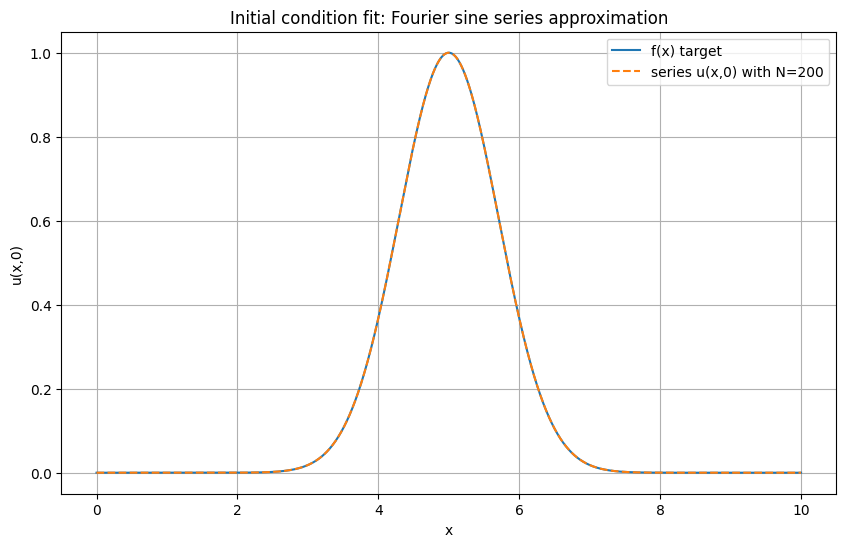

Initial condition error:
Max abs error (L∞): 1.388803269329988e-11
L2 error (approx): 1.9776176618369514e-12


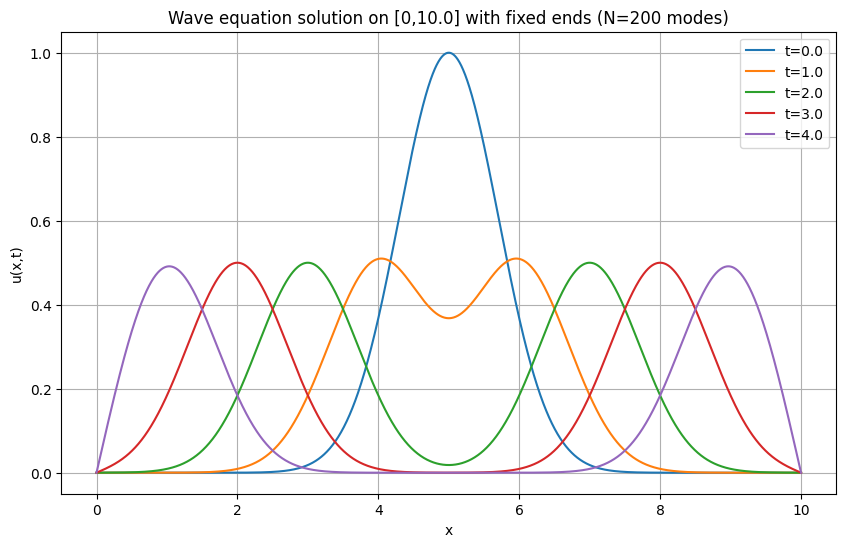

In [ ]:
# Let's setup the problem
L = 10.0
c = 1.0 # I just picked c = 1.0

def f_init(x):
    return np.exp(-(x - 5.0)**2)  # f(x) = e^{-(x-5)^2}

def g_init(x):
    return 0.0*x                  # g(x) = 0

# 1) Substitute u=X(x)T(t) and derive separated ODEs

# u = X T -> u_tt = X T'' , u_xx = X'' T
# PDE: X T'' = c^2 X'' T
# Then, divide by c^2 X T (assuming nonzero like from class):
# (T''/(c^2 T)) = (X''/X) = -lambda

# So separated ODEs are these:
#   X'' + lambda X = 0
#   T'' + c^2 lambda T = 0

# 2) Determining separation constant for nontrivial BC solutions

# BCs: u(0,t)=0 and u(L,t)=0 -> X(0)=0 and X(L)=0

# Consider cases:
# lambda = 0: X''=0 -> X = Ax + B, BCs force A=B=0 -> trivial
# lambda < 0: lambda = -mu^2 -> X'' - mu^2 X=0 -> X=A sinh(mu x)+B cosh(mu x)
# BCs force A=B=0 -> trivial

# Therefore, we need lambda > 0 for nontrivial:
# lambda = (n*pi/L)^2, n=1,2,3,...

# Then the spatial eigenfunctions are:
# X_n(x) = sin(n*pi*x/L)

# 3) Allowed eigenvalues lambda_n
def lambda_n(n, L=L):
    return (n*np.pi/L)**2

# 4) Corresponding eigenfunctions X_n(x)
def X_n(x, n, L=L):
    return np.sin(n*np.pi*x/L)

# 5) Plot the normal modes n=1,2,3,4
x_plot = np.linspace(0, L, 800)
plt.figure(figsize=(10,6))
for n in [1,2,3,4]:
    plt.plot(x_plot, X_n(x_plot, n), label=f"n={n}")
plt.title("Normal modes for fixed ends: $X_n(x)=\\sin(n\\pi x/L)$ (L=10)")
plt.xlabel("x")
plt.ylabel("X_n(x)")
plt.grid(True)
plt.legend()
plt.show()

print("Structure you should notice:")
print("- Each mode is a sine wave with nodes at x=0 and x=L.")
print("- Mode n has n half-waves on [0,L] and (n-1) interior nodes.")
print("- Higher n -> more oscillations -> captures finer spatial detail in the solution.")
print("- The solution is a sum of modes; as N → ∞ you can represent more complicated shapes is what I am understanding.")


# 6) General series solution and how A_n, B_n are determined

# With lambda_n=(nπ/L)^2, the time ODE is the following one:
#   T_n'' + c^2 (nπ/L)^2 T_n = 0
# so this means,
#   T_n(t) = A_n cos(ω_n t) + B_n sin(ω_n t)
# where ω_n = c nπ/L

# General solution:
#   u(x,t) = Σ_{n=1}^∞ [ A_n cos(ω_n t) + B_n sin(ω_n t) ] sin(nπx/L)

# Use initial conditions:
#   u(x,0)=f(x) = Σ A_n sin(nπx/L)
#   u_t(x,0)=g(x) = Σ (ω_n B_n) sin(nπx/L)

# Therefore A_n and B_n are sine-series coefficients:
#   A_n = (2/L) ∫_0^L f(x) sin(nπx/L) dx
#   B_n = (2/(L ω_n)) ∫_0^L g(x) sin(nπx/L) dx

def omega_n(n, c=c, L=L):
    return c*n*np.pi/L

# 7) Solve numerically for f(x)=e^{-(x-5)^2}, g(x)=0 using Fourier sine series

# We will now have to compute A_n numerically
# Since g=0, all B_n=0

def compute_coeffs_sine_series(f, g, N, L=L, c=c, Nx_int=2000):
    x = np.linspace(0, L, Nx_int)
    fx = f(x)
    gx = g(x)
    A = np.zeros(N+1) #1 ... N used so that is why N+1 is what I pick
    B = np.zeros(N+1)

    for n in range(1, N+1):
        sn = np.sin(n*np.pi*x/L)
        A[n] = (2.0/L) * np.trapezoid(fx * sn, x)
        wn = omega_n(n, c=c, L=L)
        B[n] = (2.0/(L*wn)) * np.trapezoid(gx * sn, x)
    return A, B

def u_series(x, t, A, B, N, L=L, c=c):
    # Evaluate u(x,t) = Σ [A_n cos(ω_n t) + B_n sin(ω_n t)] sin(nπx/L)
    x = np.asarray(x)
    u = np.zeros_like(x, dtype=float)
    for n in range(1, N+1):
        wn = omega_n(n, c=c, L=L)
        u += (A[n]*np.cos(wn*t) + B[n]*np.sin(wn*t)) * np.sin(n*np.pi*x/L)
    return u

# Now I can choose the number of modes
N = 200 # just a large number for smoothness
A, B = compute_coeffs_sine_series(f_init, g_init, N=N, L=L, c=c)

print(f"Used N = {N} sine modes for the Fourier series approximation.")

# Check how well u(x,0) matches f(x)
x = np.linspace(0, L, 2000)
u0_approx = u_series(x, 0.0, A, B, N=N, L=L, c=c)
f0 = f_init(x)

plt.figure(figsize=(10,6))
plt.plot(x, f0, label="f(x) target")
plt.plot(x, u0_approx, "--", label=f"series u(x,0) with N={N}")
plt.title("Initial condition fit: Fourier sine series approximation")
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.grid(True)
plt.legend()
plt.show()

err_inf = np.max(np.abs(u0_approx - f0))
err_L2  = np.sqrt(np.trapezoid((u0_approx - f0)**2, x))
print("Initial condition error:")
print("Max abs error (L∞):", err_inf)
print("L2 error (approx):", err_L2)

# Plot solution for different times
times = [0.0, 1.0, 2.0, 3.0, 4.0]
plt.figure(figsize=(10,6))
for t in times:
    ut = u_series(x, t, A, B, N=N, L=L, c=c)
    plt.plot(x, ut, label=f"t={t}")
plt.title(f"Wave equation solution on [0,{L}] with fixed ends (N={N} modes)")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.grid(True)
plt.legend()
plt.show()

### 1.3 Dispersion Relationship

Dispersion relation for 1-D wave equation:
    ω^2 = c^2 k^2
So: ω(k) = ± c k


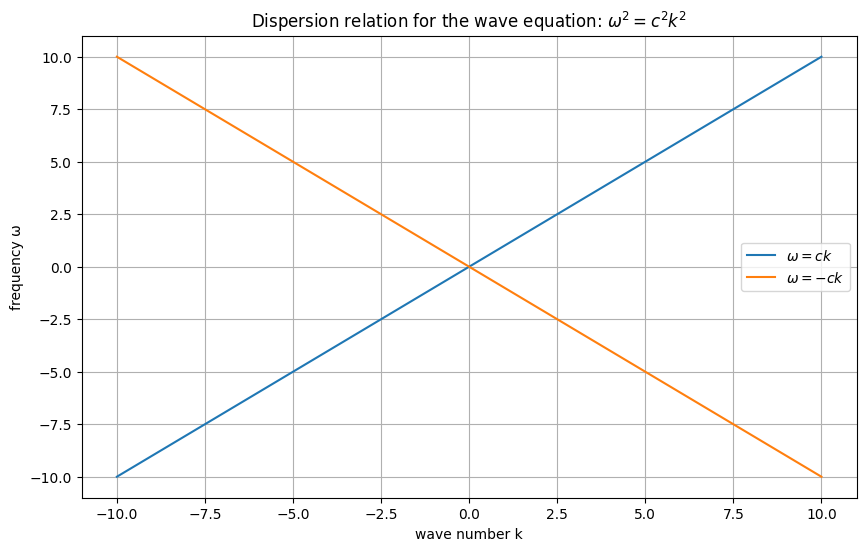

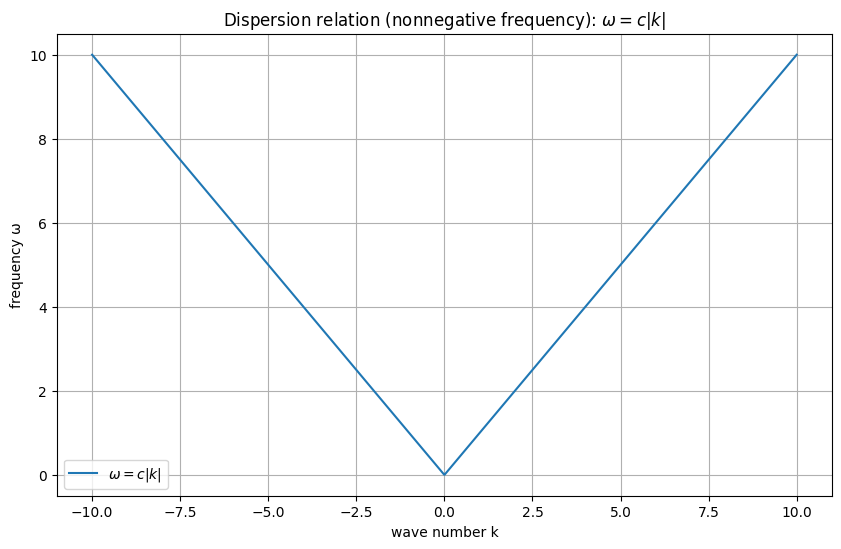


Physical meaning/takeaway that I am getting:
- Since ω is linear in k, phase velocity v_p = ω/k = ±c is constant (for k≠0).
- Group velocity v_g = dω/dk = ±c is also constant.
- Because v_p and v_g do NOT depend on k, the equation is NON-dispersive.
- So if you start with a specific wave 'packet', it moves left/right at speed c
  without changing shape (no spreading).


In [ ]:
# Parameters
c = 1.0 # just for simplicity


# 1) Plug plane wave into PDE and derive dispersion relation

# u(x,t) = A e^{i(kx - ωt)}
# u_t = (-iω) A e^{i(kx-ωt)}
# u_tt = (-iω)^2 A e^{i(kx-ωt)} = (-ω^2) A e^{i(kx-ωt)}

# u_x = (ik) A e^{i(kx-ωt)}
# u_xx = (ik)^2 A e^{i(kx-ωt)} = (-k^2) A e^{i(kx-ωt)}

# Plug into u_tt = c^2 u_xx to get this:
#  (-ω^2) A e^{i(...)} = c^2 (-k^2) A e^{i(...)}
# Cancel common factor A e^{i(...)} (nonzero):
#  ω^2 = c^2 k^2

# Dispersion relation:
# ω(k) = ± c k  (or ω = c|k| if you want ω nonnegative)

print("Dispersion relation for 1-D wave equation:")
print("    ω^2 = c^2 k^2")
print("So: ω(k) = ± c k")


# 2) Plot ω vs k with k on x-axis

k = np.linspace(-10, 10, 2000)
omega_plus  =  c * k
omega_minus = -c * k
omega_abs   =  c * np.abs(k)

plt.figure(figsize=(10,6))
plt.plot(k, omega_plus,  label=r'$\omega = ck$')
plt.plot(k, omega_minus, label=r'$\omega = -ck$')
plt.title("Dispersion relation for the wave equation: $\\omega^2=c^2k^2$")
plt.xlabel("wave number k")
plt.ylabel("frequency ω")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(k, omega_abs, label=r'$\omega = c|k|$')
plt.title("Dispersion relation (nonnegative frequency): $\\omega=c|k|$")
plt.xlabel("wave number k")
plt.ylabel("frequency ω")
plt.grid(True)
plt.legend()
plt.show()


# 3) Physical meaning

# Phase velocity: v_p = ω/k = ±c (for k≠0)
# Group velocity: v_g = dω/dk = ±c

# Both are constants (independent of k): no dispersion
# Meaning: different wavelengths travel at the same speed, so a wave "packet" (the word we used in class)
# does NOT spread out. Therefore, its shape translates without changing form.

print("\nPhysical meaning/takeaway that I am getting:")
print("- Since ω is linear in k, phase velocity v_p = ω/k = ±c is constant (for k≠0).")
print("- Group velocity v_g = dω/dk = ±c is also constant.")
print("- Because v_p and v_g do NOT depend on k, the equation is NON-dispersive.")
print("- So if you start with a specific wave 'packet', it moves left/right at speed c")
print("  without changing shape (no spreading).")